# Anomaly Flight Logs Data Cleaning

## Import Statements

In [1]:
pip install xgboost

In [2]:
# File systems
import os
from google.colab import drive

# Data structures
import pandas as pd
import numpy as np

# Import visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Import ML tools
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Import tools for preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Import metrics to evaluate performance
from sklearn.metrics import classification_report, confusion_matrix, log_loss
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.metrics import average_precision_score

# Save model
import joblib

## Get the two datasets

In [3]:
# Mount the drive
drive.mount('/content/drive')

Mounted at /content/drive


### Get the base dataset showing flight paths and anomalies from structured logs:

In [4]:
# Get the flight path anomaly dataset
path03 = "/content/drive/MyDrive/FlightForensics/data/flight_logs/cleaned_18-06-19-02-04-47_anomaly_log.csv"
path04 = '/content/drive/MyDrive/FlightForensics/data/flight_logs/cleaned_18-06-19-02-11-31_anomaly_log.csv'

flight03_path = pd.read_csv(path03)
flight04_path = pd.read_csv(path04)

In [5]:
# Convert flight path anomaly dataset into DataFrame format
flight03_anomaly = pd.DataFrame(flight03_path)
flight04_anomaly = pd.DataFrame(flight04_path)

Create flight identifiers to show two different flights:

In [6]:
# Add flight sequence to each column to show two separate flights
flight03_anomaly["flight_sequence"] = "flight03"
flight04_anomaly["flight_sequence"] = "flight04"

Ran a script ensuring same columns, so concat both datasets:

In [7]:
# Combine datasets
flight_anomaly = pd.concat([flight03_anomaly, flight04_anomaly])

In [8]:
# Look at the first five rows
flight_anomaly.head()

,clock_offset,imu_longitude,imu_latitude,imu_rel_height,roll,pitch,yaw,accel_x,accel_y,accel_z,...,hover_point_uncertainty2,hover_point_uncertainty3,hover_point_uncertainty4,hover_point_uncertainty5,hover_point_uncertainty6,velocity_uncertainty1,velocity_uncertainty3,velocity_uncertainty4,velocity_uncertainty6,flight_sequence
0,-344.350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,flight03
1,0.000,-106.216454,39.961194,-2.224854,1.097724,-2.153399,-117.847337,-0.037371,-0.019999,-1.008184,...,0.0,0.0,0.00169,0.0,0.00169,0.000106,0.340574,0.000106,0.000106,flight03
2,0.039,-106.216454,39.961194,-0.546142,1.119289,-2.155384,-117.846310,-0.036579,-0.020031,-1.008412,...,0.0,0.0,0.00169,0.0,0.00169,0.000106,0.340574,0.000106,0.000106,flight03
3,0.101,-106.216454,39.961194,-0.546142,1.119289,-2.155384,-117.846310,-0.036579,-0.020031,-1.008412,...,0.0,0.0,0.00169,0.0,0.00169,0.000106,0.340574,0.000106,0.000106,flight03
4,0.143,-106.216454,39.961194,-0.959717,1.119977,-2.177045,-118.033396,-0.030232,-0.039988,-1.011359,...,0.0,0.0,0.00169,0.0,0.00169,0.000106,0.340574,0.000106,0.000106,flight03


### Clean up the datatypes

Ensure appropriate data types for the model:

In [9]:
# Check flight_anomaly data types
flight_anomaly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9045 entries, 0 to 5621
Data columns (total 69 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   clock_offset               9045 non-null   float64
 1   imu_longitude              9042 non-null   float64
 2   imu_latitude               9042 non-null   float64
 3   imu_rel_height             3422 non-null   float64
 4   roll                       9042 non-null   float64
 5   pitch                      9042 non-null   float64
 6   yaw                        9042 non-null   float64
 7   accel_x                    9042 non-null   float64
 8   accel_y                    9042 non-null   float64
 9   accel_z                    9042 non-null   float64
 10  accel_composite            9042 non-null   float64
 11  gyro_x                     9042 non-null   float64
 12  gyro_z                     9042 non-null   float64
 13  gyro_composite             9042 non-null   float64
 1

Clean up the incompatible data types:

In [10]:
# Convert gps_timestamp to dateTime format
flight_anomaly["gps_timestamp"] = pd.to_datetime(flight_anomaly["gps_timestamp"], errors="coerce", utc=True)

In [11]:
# Convert the objects into boolean data types
boolean_columns = ["pos_error", "oa_emergency_brake"]
flight_anomaly[boolean_columns] = flight_anomaly[boolean_columns].astype(bool)

In [12]:
# Force conversion to string
flight_anomaly["control_mode"] = flight_anomaly["control_mode"].astype("string")
flight_anomaly["flight_sequence"] = flight_anomaly["flight_sequence"].astype("string")

In [13]:
# Check for successful conversions
flight_anomaly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9045 entries, 0 to 5621
Data columns (total 69 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   clock_offset               9045 non-null   float64            
 1   imu_longitude              9042 non-null   float64            
 2   imu_latitude               9042 non-null   float64            
 3   imu_rel_height             3422 non-null   float64            
 4   roll                       9042 non-null   float64            
 5   pitch                      9042 non-null   float64            
 6   yaw                        9042 non-null   float64            
 7   accel_x                    9042 non-null   float64            
 8   accel_y                    9042 non-null   float64            
 9   accel_z                    9042 non-null   float64            
 10  accel_composite            9042 non-null   float64            
 11  gyro_x   

### Check missing values

In [14]:
flight_anomaly.isna().sum()

,0
clock_offset,0
imu_longitude,3
imu_latitude,3
imu_rel_height,5623
roll,3
...,...
velocity_uncertainty1,4
velocity_uncertainty3,4
velocity_uncertainty4,4
velocity_uncertainty6,4


Remove imu_rel_height due to excessive missing values:

In [15]:
# drop imu_rel_height attribute
flight_anomaly.drop("imu_rel_height", axis=1, inplace=True)

Fix missing numeric values if minimal through interpolation:

In [16]:
# Obtain only numeric features
numeric_features = flight_anomaly.select_dtypes(include=["int64", float])

# Use interpolation to fix null values in numeric attributes
numeric_features = numeric_features.interpolate(method="linear", limit_direction="both")


Ensure that there are no missing values after cleaning:

In [17]:
# Check if there is any missed NaN values
numeric_features.isna().sum()

,0
clock_offset,0
imu_longitude,0
imu_latitude,0
roll,0
pitch,0
...,...
hover_point_uncertainty6,0
velocity_uncertainty1,0
velocity_uncertainty3,0
velocity_uncertainty4,0


# Data Exploration

## Skewed Data

Check feature distributions to determine whether data is skewed:

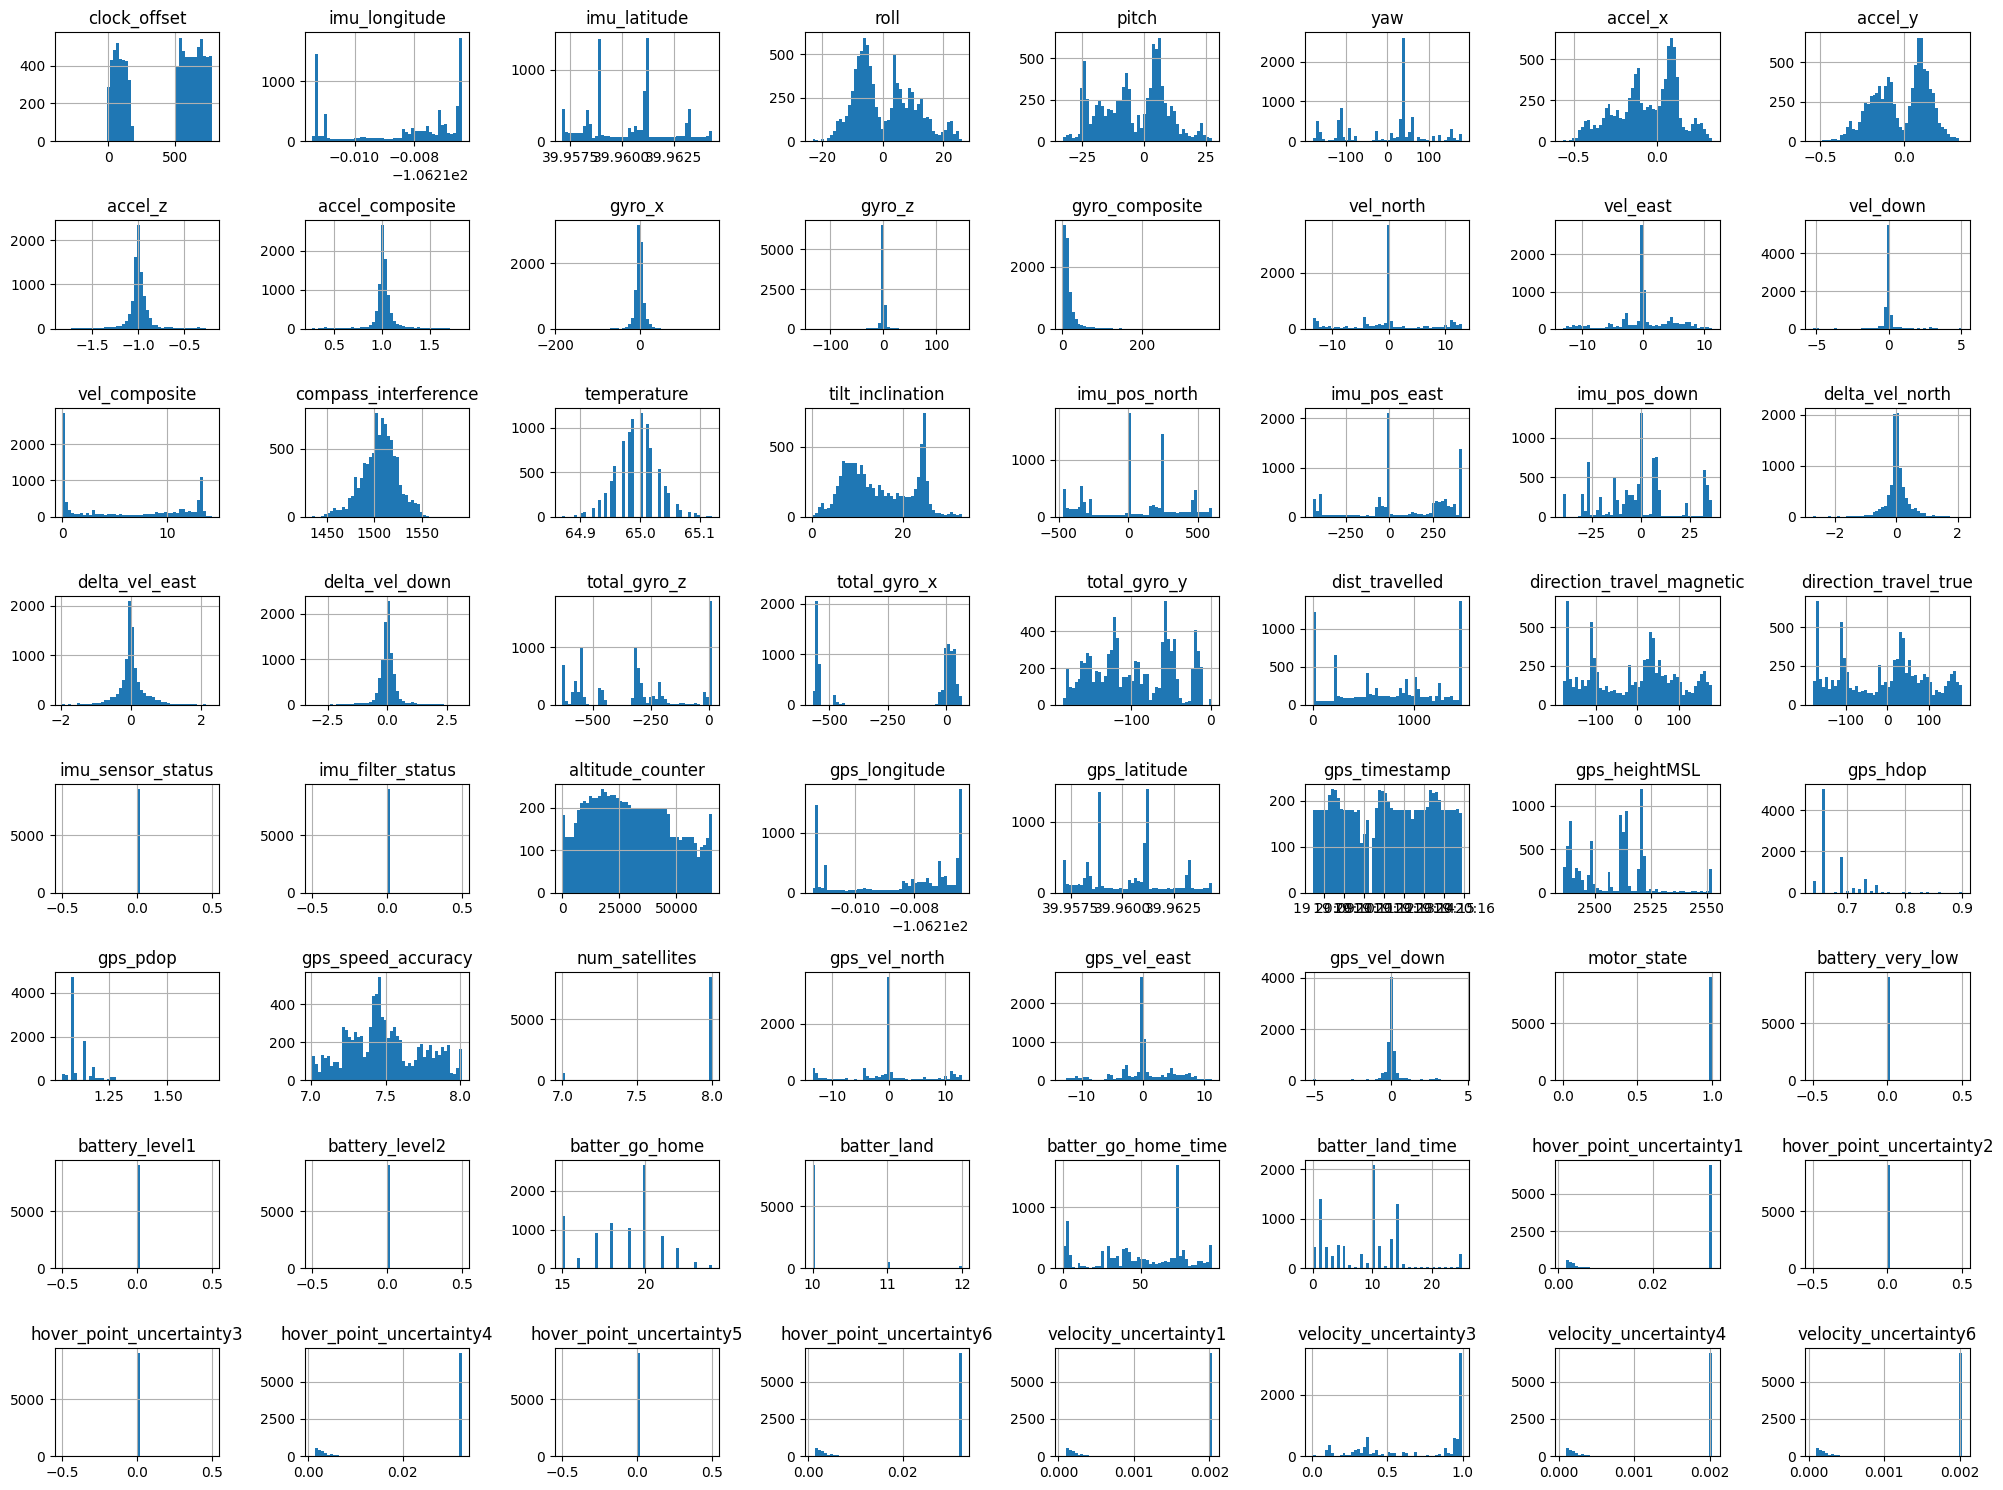

In [18]:
# Create a histogram displaying feature distributions
flight_anomaly.hist(bins=50,
                    figsize=(20, 15))

plt.tight_layout()
plt.show()

Normal distribution: temperature, roll, pitch, and gps_timestamps

Right-skewed: aceel_z, vel_down, dist_travelled, gyro_composite, vel_deposite_altitude_counter

Left-skewed: hover_point_uncertaintyX, velocity_uncertaintyX, imu_pos_north, delta_vel_north

## Redundant or Noisy Features

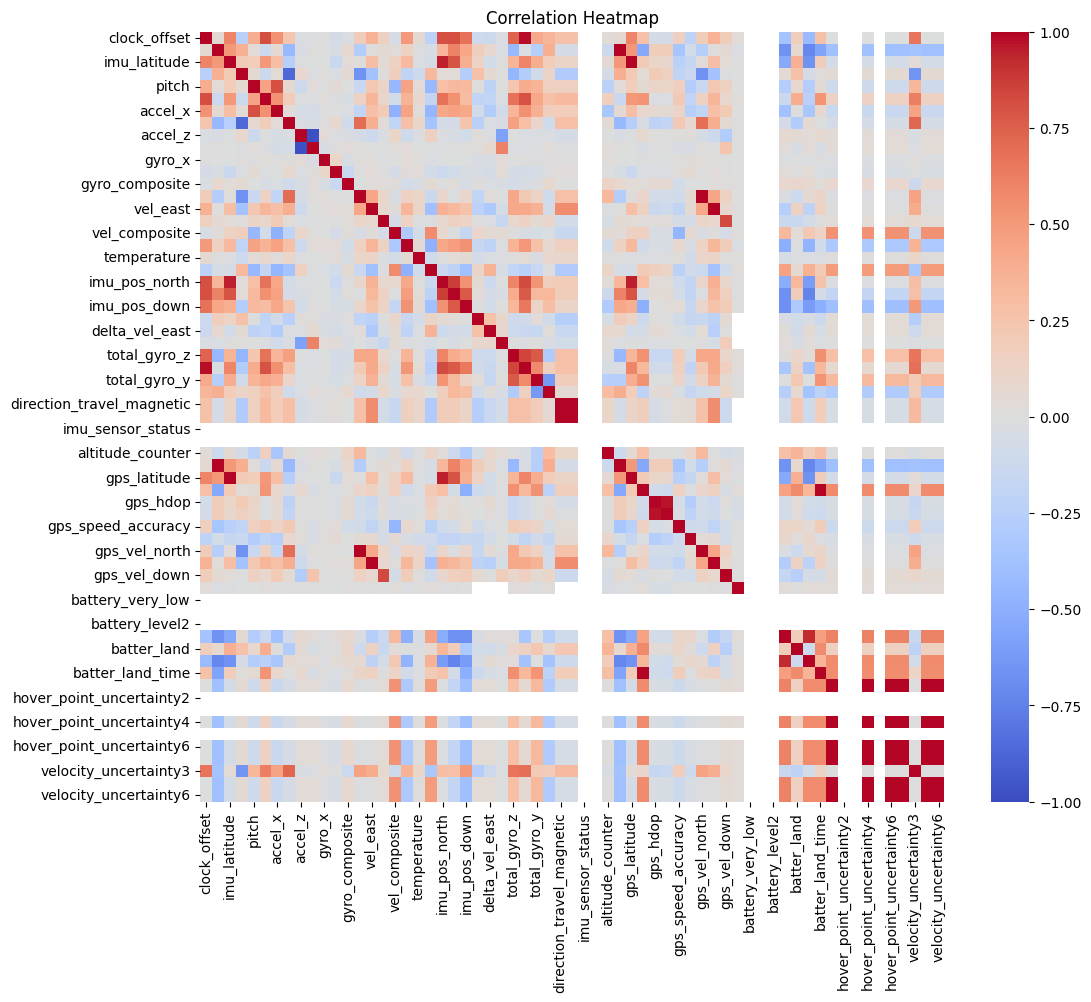

In [19]:
# Utilize corrrelation matric to spot high correlations among features

# Get numerical data
numeric_features = flight_anomaly.select_dtypes(include=["int64", float])

# Calculate correlation matrix
corr_matrix = numeric_features.corr()
plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix,
            cmap="coolwarm",
            vmax=1.0,
            vmin=-1.0)

plt.title("Correlation Heatmap")
plt.show()

The correlation matrix indicates redundancy in features which may introduce noise.

 Must drop these features:

In [20]:
drop_cols = [
    'gyro_x', 'gyro_z',  # keep gyro_composite
    'vel_north', 'vel_east', 'vel_down',  # keep vel_composite
    'hover_point_uncertainty1', 'hover_point_uncertainty2', 'hover_point_uncertainty4',
    'hover_point_uncertainty5', 'hover_point_uncertainty6',  # keep 3
    'velocity_uncertainty1', 'velocity_uncertainty4', 'velocity_uncertainty6',  # keep 3
    'motor_state', 'battery_level2', 'batter_land', 'imu_sensor_status', 'imu_filter_status'  # flat or near-constant
]

flight_anomaly.drop(columns=drop_cols, inplace=True)

## Time Dependency

Visualize key time series - features that are time dependent:


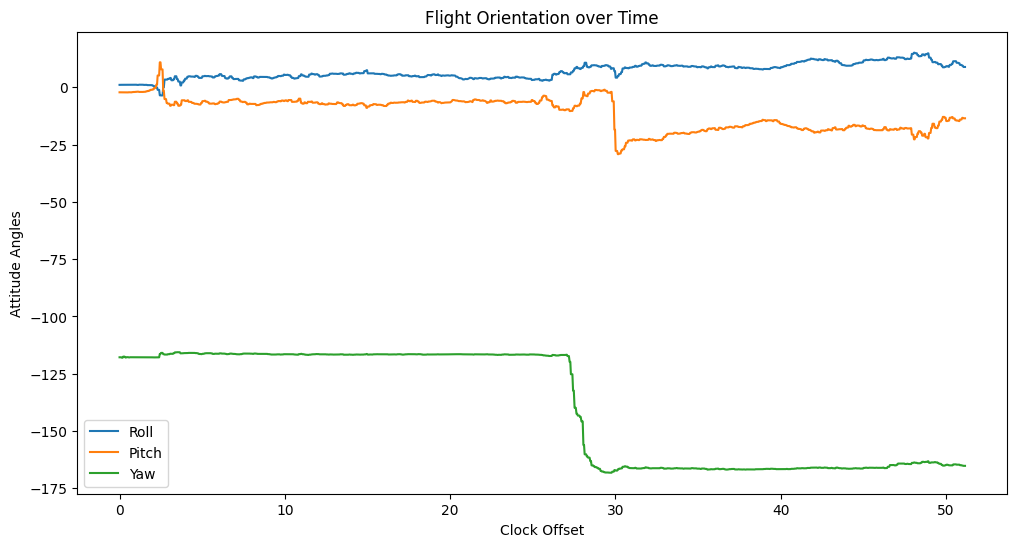

In [21]:
sample = flight_anomaly.iloc[:1000]  # sample to keep the plot readable

plt.figure(figsize=(12, 6))

# Clock vs. roll
plt.plot(sample['clock_offset'],
         sample['roll'],
         label='Roll')

# Clock vs. Pitch
plt.plot(sample['clock_offset'],
         sample['pitch'],
         label='Pitch')

# Clock vs. Yaw
plt.plot(sample['clock_offset'],
         sample['yaw'],
         label='Yaw')

plt.xlabel("Clock Offset")
plt.ylabel("Attitude Angles")
plt.legend()
plt.title("Flight Orientation over Time")
plt.show()


Based on this visualization, anomalies may occur around clock offset = 28 based on the sharp drop.

## Find Outliers

Identify outliers graphically to compare with Isolation Forest performance:

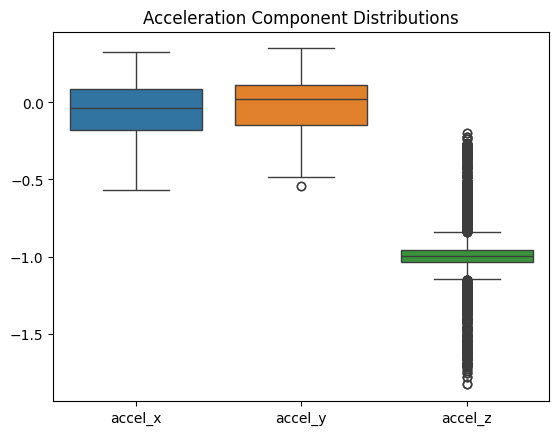

In [22]:
# Check acceleration attributes using boxplots
sns.boxplot(data=flight_anomaly[['accel_x',
                                 'accel_y',
                                 'accel_z']])

plt.title("Acceleration Component Distributions")
plt.show()

accel_z is heavily skewed and has a long tail of outliers. It shows that this feature is a strong candidate for indicating anomalies.

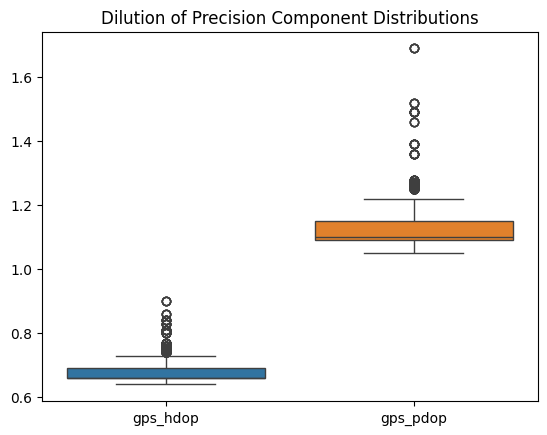

In [23]:
# Check dilution of precision attributes using boxplots
sns.boxplot(data=flight_anomaly[["gps_hdop",
                                 "gps_pdop"]])

plt.title("Dilution of Precision Component Distributions")
plt.show()

gps_pdop could indicate that GPS-based altitude/position data is less trustworthy, which may negatively affect model due to less accuracy in measurements.

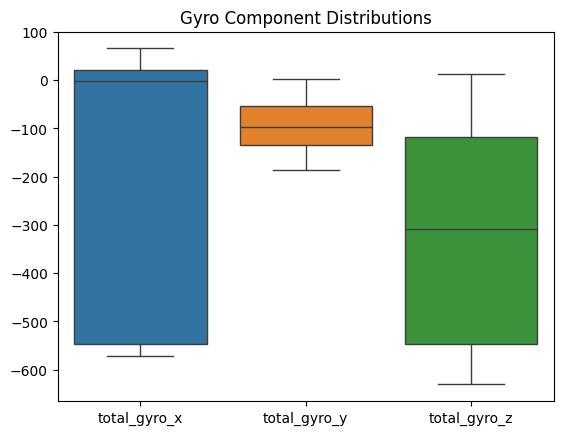

In [24]:
# Check drone rotations using boxplots
sns.boxplot(data=flight_anomaly[["total_gyro_x",
                                 "total_gyro_y",
                                 "total_gyro_z"]])

plt.title("Gyro Component Distributions")
plt.show()

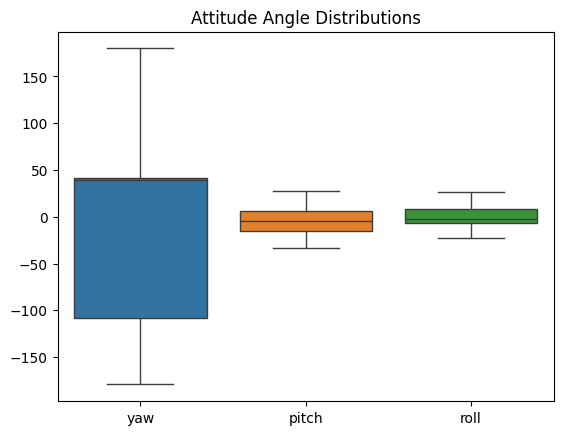

In [25]:
# Check yaw, pitch, and roll
sns.boxplot(data=flight_anomaly[["yaw",
                                 "pitch",
                                 "roll"]])

plt.title("Attitude Angle Distributions")
plt.show()

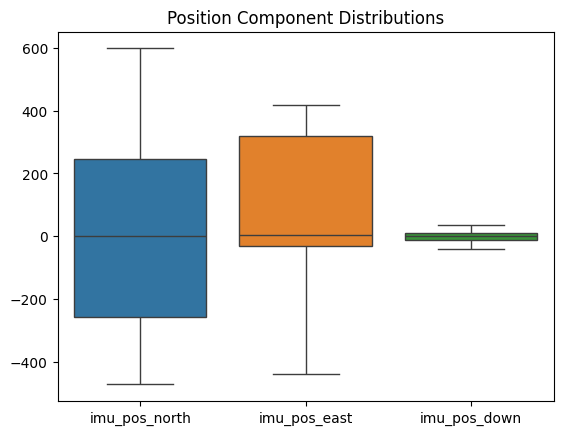

In [26]:
# Check positions using boxplots
sns.boxplot(data=flight_anomaly[["imu_pos_north",
                                 "imu_pos_east",
                                 "imu_pos_down"]])

plt.title("Position Component Distributions")
plt.show()

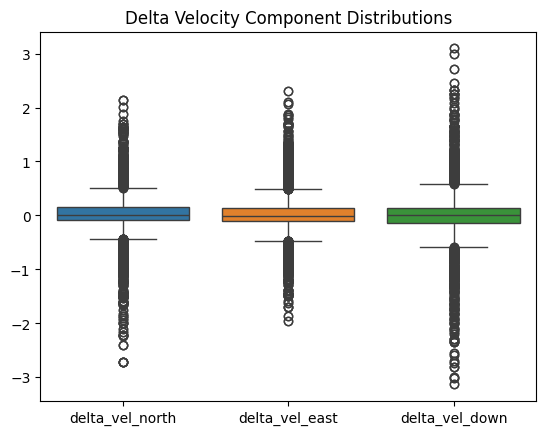

In [27]:
# Check velocity attributes
sns.boxplot(data=flight_anomaly[["delta_vel_north",
                                 "delta_vel_east",
                                 "delta_vel_down"]])

plt.title("Delta Velocity Component Distributions")
plt.show()

Many symmetric outliers on both ends indicating possible dramatic vertical changes leading to anomalies.

# Data Visualization

## Compare flight paths

In [28]:
print(flight_anomaly["flight_sequence"].unique())

<StringArray>
['flight03', 'flight04']
Length: 2, dtype: string


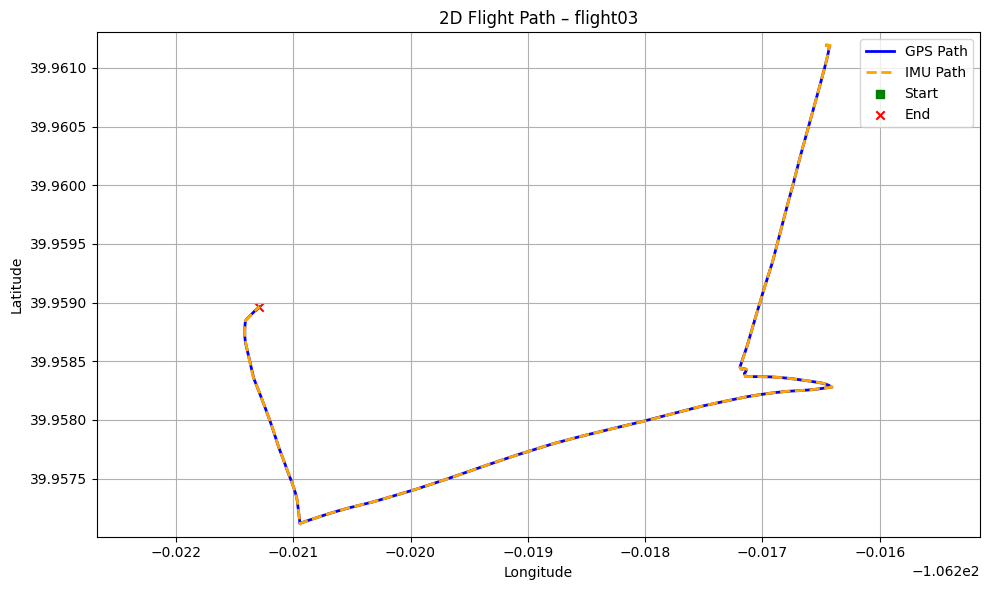

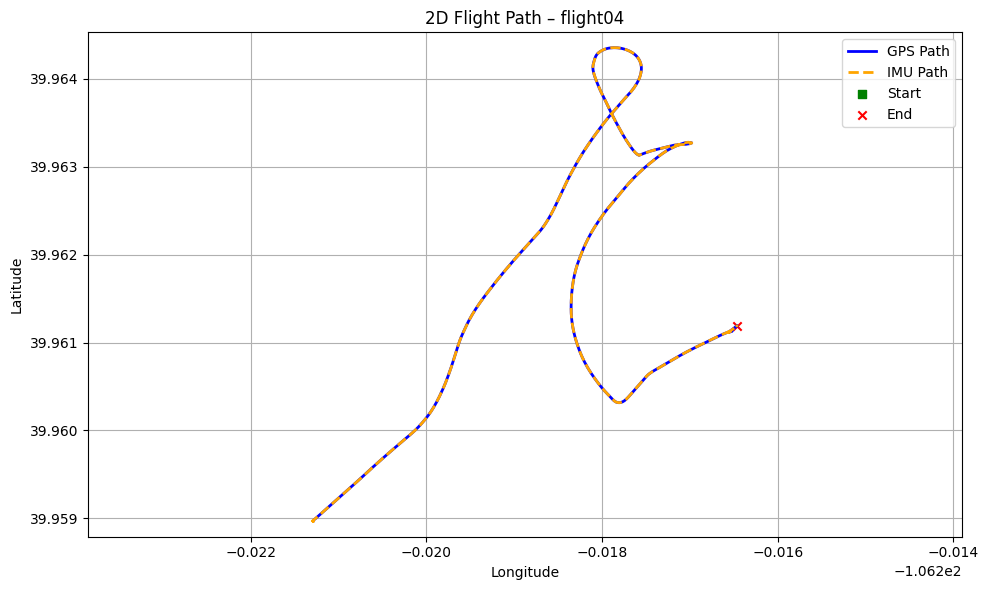

In [29]:
# Get unique flight IDs
unique_flights = flight_anomaly["flight_sequence"].unique()

# Loop through each flight and create its own plot
for flight_id in unique_flights:
    group = flight_anomaly[flight_anomaly["flight_sequence"] == flight_id]

    plt.figure(figsize=(10, 6))

    # GPS path
    plt.plot(group["gps_longitude"],
             group["gps_latitude"],
             color="blue",
             label="GPS Path",
             linewidth=2)

    # IMU path
    plt.plot(group["imu_longitude"],
             group["imu_latitude"],
             color="orange",
             linestyle="--",
             label="IMU Path",
             linewidth=2)

    # Start and end markers
    plt.scatter(group["gps_longitude"].iloc[0],
                group["gps_latitude"].iloc[0],
                color="green",
                marker="s",      # s = START
                label="Start")

    plt.scatter(group["gps_longitude"].iloc[-1],
                group["gps_latitude"].iloc[-1],
                color="red",
                marker="x",     # x = END
                label="End")

    plt.title(f"2D Flight Path – {flight_id}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Predictive Features over Time

Altitude over time:

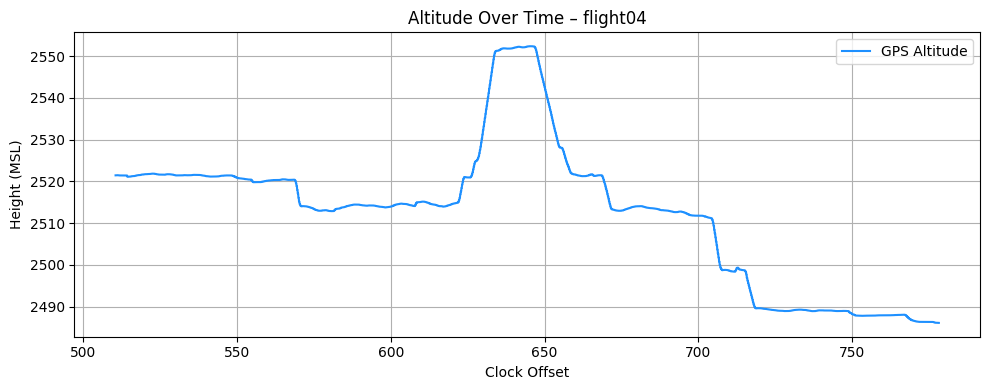

In [30]:
plt.figure(figsize=(10, 4))

plt.plot(group["clock_offset"],   # Time vs.
         group["gps_heightMSL"],  #         Height
         label="GPS Altitude",
         color="dodgerblue")

plt.title(f"Altitude Over Time – {flight_id}")
plt.xlabel("Clock Offset")
plt.ylabel("Height (MSL)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Position over time:

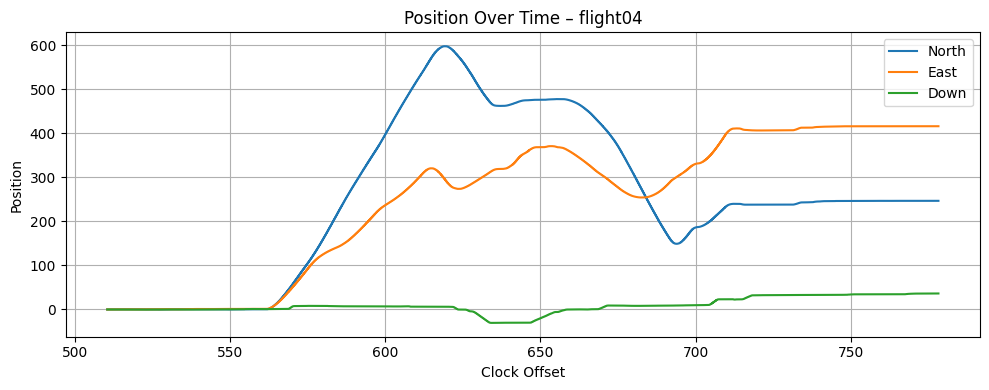

In [31]:
plt.figure(figsize=(10, 4))

# Plot time vs north
plt.plot(group["clock_offset"],
         group["imu_pos_north"],
         label="North")

# Plot time vs east
plt.plot(group["clock_offset"],
         group["imu_pos_east"],
         label="East")

# Plot time vs down
plt.plot(group["clock_offset"],
         group["imu_pos_down"],
         label="Down")

plt.title(f"Position Over Time – {flight_id}")
plt.xlabel("Clock Offset")
plt.ylabel("Position")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Acceleration over time:

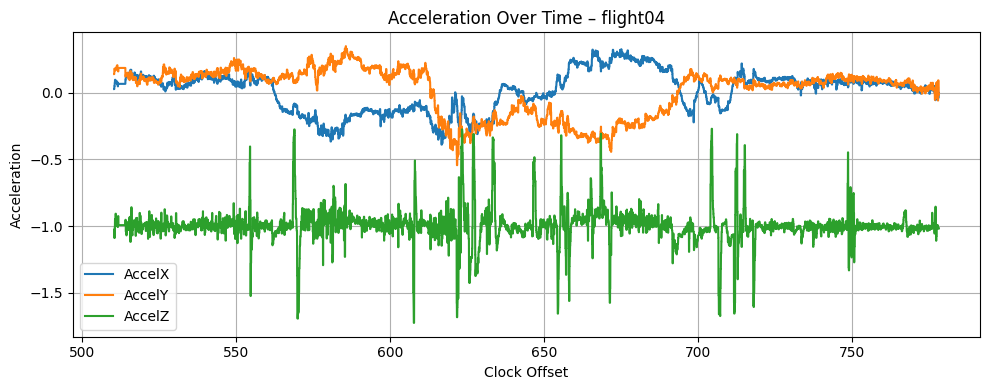

In [32]:
plt.figure(figsize=(10, 4))

# Plot time vs Acceleration X
plt.plot(group["clock_offset"],
         group["accel_x"],
         label="AccelX")

# Plot time vs. Acceleration Y
plt.plot(group["clock_offset"],
         group["accel_y"],
         label="AccelY")

# Plot time vs. Acceleration Z
plt.plot(group["clock_offset"],
         group["accel_z"],
         label="AccelZ")

plt.title(f"Acceleration Over Time – {flight_id}")
plt.xlabel("Clock Offset")
plt.ylabel("Acceleration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Plot velocity over time:

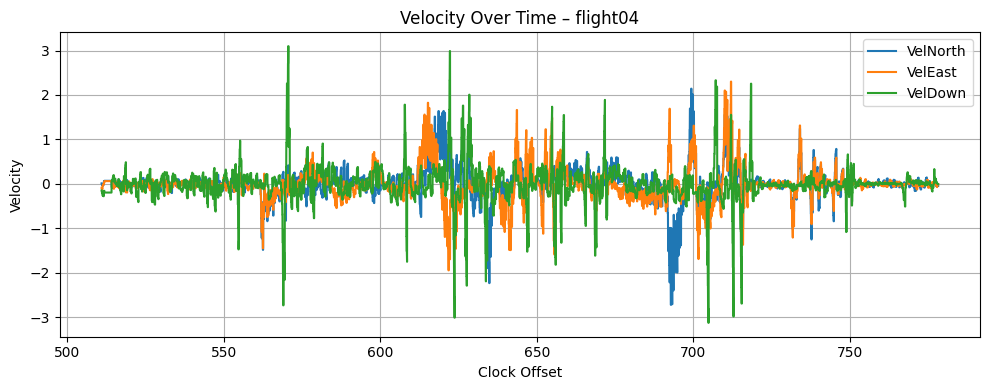

In [33]:
plt.figure(figsize=(10, 4))

# Plot time vs. Velocity North
plt.plot(group["clock_offset"],
         group["delta_vel_north"],
         label="VelNorth")

# Plot time vs. Velocity East
plt.plot(group["clock_offset"],
         group["delta_vel_east"],
         label="VelEast")

# Plot time vs Velocity Down
plt.plot(group["clock_offset"],
         group["delta_vel_down"],
         label="VelDown")

plt.title(f"Velocity Over Time – {flight_id}")
plt.xlabel("Clock Offset")
plt.ylabel("Velocity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Deviations between IMU and Deviation over time

<ipython-input-34-7dbd9669650b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group["coord_deviation"] = np.sqrt(


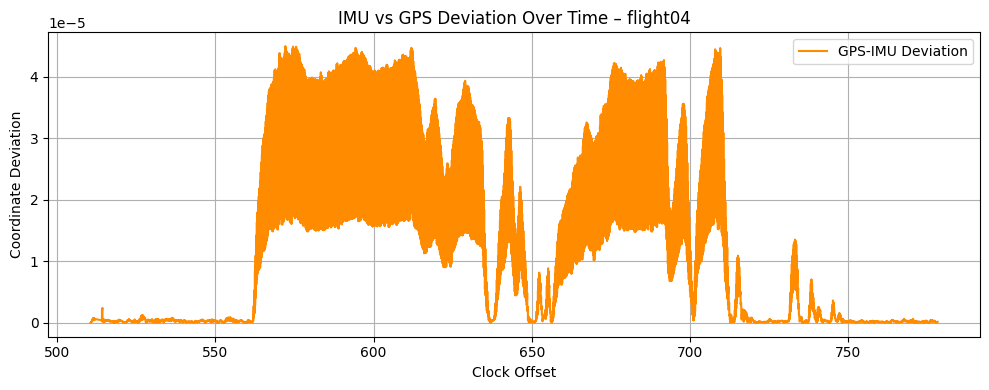

In [34]:
# We want to use euclidean distance to find deviations
  # coord_deviation = √((gps_lat - imu_lat)^2 + (gps_long - imu_long)^2)
group["coord_deviation"] = np.sqrt(
    (group["gps_latitude"] - group["imu_latitude"])**2 +
    (group["gps_longitude"] - group["imu_longitude"])**2
)

plt.figure(figsize=(10, 4))

# Plot computed deviations
plt.plot(group["clock_offset"],
         group["coord_deviation"],
         label="GPS-IMU Deviation",
         color="darkorange")

plt.title(f"IMU vs GPS Deviation Over Time – {flight_id}")
plt.xlabel("Clock Offset")
plt.ylabel("Coordinate Deviation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Initialize & Train the Unsupervised Model

Unsupervised learning method using isolation forests to create labels to train a supervised learning model later.

The reason for isolation forest model is due to effectiveness for high-dimensional anomaly detection. It assumes anomalies are rare, and works well with noisy data. Additionally, it complements the dataset due to time-series ordering.



In [35]:
# Initialize model
iso = IsolationForest(contamination=0.02, random_state=42)

In [36]:
# Train the unsupervised model
iso.fit(numeric_features)

IsolationForest(contamination=0.02, random_state=42)

In [37]:
# Get predictions
labels = iso.predict(numeric_features)
scores = iso.decision_function(numeric_features)

In [41]:
flight_anomaly["anomaly_label"] = labels
flight_anomaly["anomaly_score"] = scores

In [42]:
flight_anomaly[flight_anomaly["anomaly_label"] == -1]

,clock_offset,imu_longitude,imu_latitude,roll,pitch,yaw,accel_x,accel_y,accel_z,accel_composite,...,battery_level1,batter_go_home,batter_go_home_time,batter_land_time,oa_emergency_brake,hover_point_uncertainty3,velocity_uncertainty3,flight_sequence,anomaly_label,anomaly_score
65,3.305,-106.216446,39.961194,3.532821,-7.764505,-116.070895,-0.153464,-0.024046,-1.058298,1.069638,...,0.0,15.0,0.0,0.0,True,0.0,0.349161,flight03,-1,-0.009215
66,3.346,-106.216446,39.961194,4.856909,-6.269127,-115.695772,-0.158478,-0.009237,-1.014475,1.026821,...,0.0,15.0,1.0,0.0,True,0.0,0.349161,flight03,-1,-0.005757
67,3.398,-106.216446,39.961194,4.856909,-6.269127,-115.695772,-0.158478,-0.009237,-1.014475,1.026821,...,0.0,15.0,1.0,0.0,True,0.0,0.349161,flight03,-1,-0.005757
68,3.434,-106.216446,39.961194,4.856909,-6.269127,-115.695772,-0.158478,-0.009237,-1.014475,1.026821,...,0.0,15.0,1.0,0.0,True,0.0,0.349161,flight03,-1,-0.005757
69,3.477,-106.216445,39.961194,3.606063,-7.066203,-115.641181,-0.066674,-0.043700,-1.030997,1.034074,...,0.0,15.0,1.0,0.0,True,0.0,0.349161,flight03,-1,-0.005813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3338,671.713,-106.217869,39.962604,22.420464,13.446624,114.248035,0.236521,-0.437212,-1.180743,1.281113,...,0.0,19.0,45.0,10.0,False,0.0,0.685661,flight04,-1,-0.003986
3339,671.748,-106.217869,39.962604,22.420464,13.446624,114.248035,0.236521,-0.437212,-1.180743,1.281113,...,0.0,19.0,45.0,10.0,False,0.0,0.687393,flight04,-1,-0.008477
4172,706.893,-106.217005,39.960910,-1.294525,-4.804270,59.543143,-0.106238,0.107759,-1.626882,1.633904,...,0.0,18.0,36.0,5.0,False,0.0,0.957045,flight04,-1,-0.003731
4173,706.931,-106.217005,39.960910,-1.294525,-4.804270,59.543143,-0.106238,0.107759,-1.626882,1.633904,...,0.0,18.0,36.0,5.0,False,0.0,0.957045,flight04,-1,-0.003731


### Visualization

Check the anomaly score vs. time for each flight:

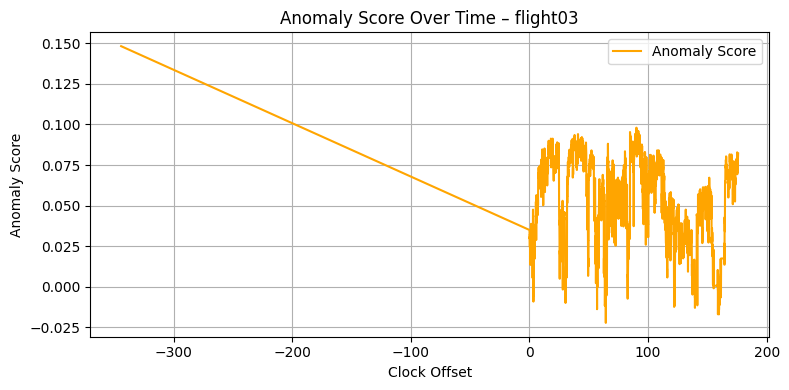

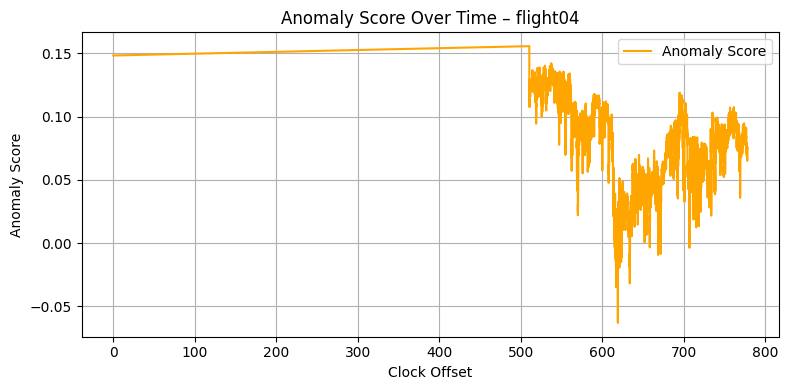

In [43]:
for flight_id, group in flight_anomaly.groupby("flight_sequence"):
    plt.figure(figsize=(8, 4))
    plt.plot(group["clock_offset"], group["anomaly_score"], label="Anomaly Score", color="orange")
    plt.title(f"Anomaly Score Over Time – {flight_id}")
    plt.xlabel("Clock Offset")
    plt.ylabel("Anomaly Score")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Model finds anomalies during flight period which is an indicator of good performance.

Highlight points labeled as anomalies:

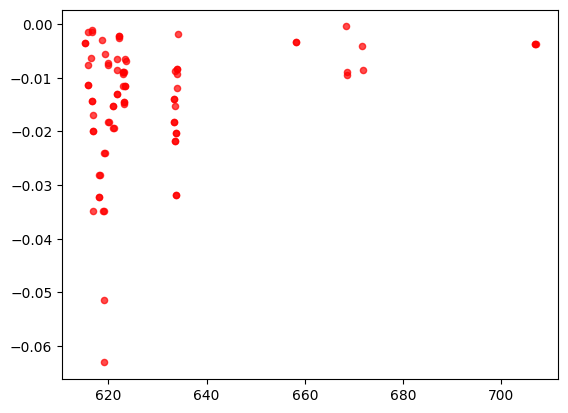

In [44]:
anomalies = group[group["anomaly_label"] == -1]

plt.scatter(anomalies["clock_offset"], anomalies["anomaly_score"],
            color='red', label="Anomaly", s=20, alpha=0.7)

Cluster of anomalies lie between the clock offset, 615 and 635, and other anomalies occur later arround 665-705. The specific points indicate that the model is picking up valid anomalies and not influenced by noise.

## Train the Supervised Learning Model

### Preprocess data

Now that we've created labels, prepare the data for training:

In [45]:
# Split up training and test sets
  # Drop columns that are incompatible or risks data leakage
X = flight_anomaly.drop(["anomaly_label", "anomaly_score", "flight_sequence",
                         "control_mode", "gps_timestamp"], axis=1)
y = flight_anomaly["anomaly_label"]

In [46]:
# Check for imbalanced classes
y.value_counts()

,count
anomaly_label,
1,8864
-1,181


In [47]:
# Ensure compatible values in y
y = y.replace({-1: 1, 1:0})

In [48]:
y.value_counts()

,count
anomaly_label,
0,8864
1,181


In [49]:
# Implement stratify splitting to handle imbalance
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

### Initialize and train the XGBoost model

XGboost model was used due to its robustness to skewed data. Additionally, it is capable of finding non-linear patterns, if exists, and good with handling noise.

 Grid search is implemented for efficient hyperparameter tuning and cross validation is used for optimal results.

In [50]:
param_grid = {
    "max_depth": [3, 6, 10],
    "learning_rate": [0.1, 0.01, 0.05],
    "n_estimators": [50, 100],
    "scale_pos_weight": [10, 25, 50]
}

In [51]:
xgb = XGBClassifier(
    objective="binary:logistic",
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
    )

In [52]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1",
    n_jobs=-1,
    cv=5,
    verbose=1
)

In [53]:
# train the model
grid.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:21:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01, 0.05],
                         'max_depth': [3, 6, 10], 'n_estimators': [50, 100],
                         'scale_pos_weight': [10, 25, 50]},
             scoring='f1', verbose=1)

In [54]:
# predict on test set
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

In [55]:
# See the best model and parameters
bes_model = grid.best_estimator_
best_params = grid.best_params_

print("Best Model:", bes_model)
print("Best Parameters:", best_params)

Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)
Best Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 50, 'scale_pos_weight': 10}


In [56]:
# Check test f1-score
grid.score(X_test, y_test)

0.9142857142857143

In [57]:
# Check test accuracy
accuracy_score(y_test, y_pred)

0.9966832504145937

In [58]:
# Check loss
log_loss(y_test, y_pred)

0.11954777243488299

In [59]:
# Check performance summary
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1773
           1       0.94      0.89      0.91        36

    accuracy                           1.00      1809
   macro avg       0.97      0.94      0.96      1809
weighted avg       1.00      1.00      1.00      1809



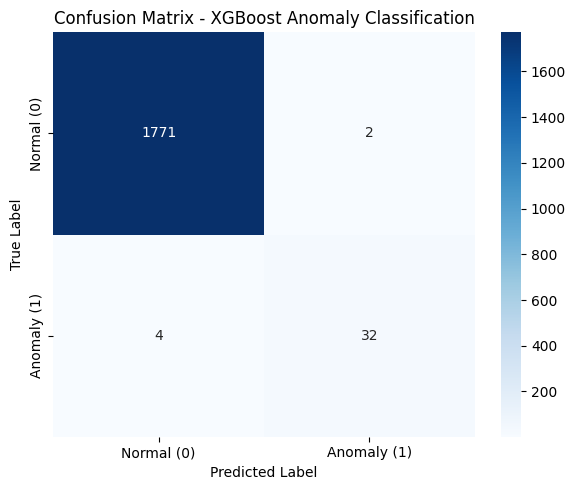

In [60]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Normal (0)", "Anomaly (1)"]

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost Anomaly Classification")
plt.tight_layout()
plt.show()

normal class (0): 1771 TN, 2 FP

Suspicious class (1): 4 FN, 32 TP

This indicates minimal misclassifications in each class.

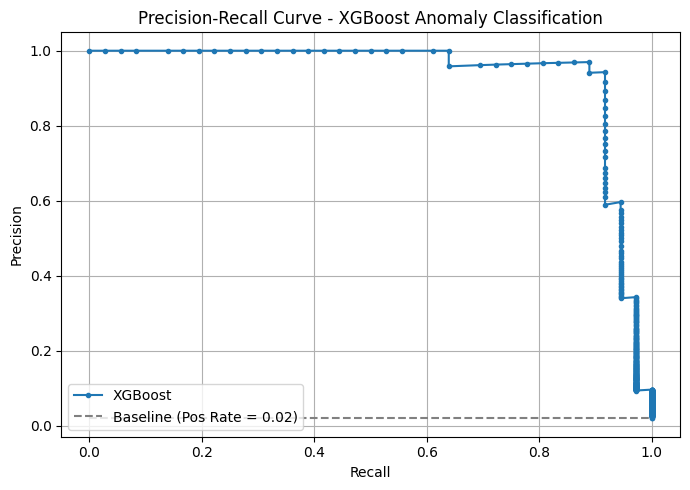

In [61]:

# Compute precision-recall values using probabilities
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
baseline = y_test.mean()

# Plot the PR curve with baseline
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, marker='.', label=f"XGBoost")
plt.hlines(baseline, 0, 1, linestyles="dashed", colors="gray", label=f"Baseline (Pos Rate = {baseline:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost Anomaly Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The precision recall curve demonstrates the class imbalances with the positive rate baseline at 2%. It is hugging the top right corner showing effective balancing the precision-recall tradeoff.

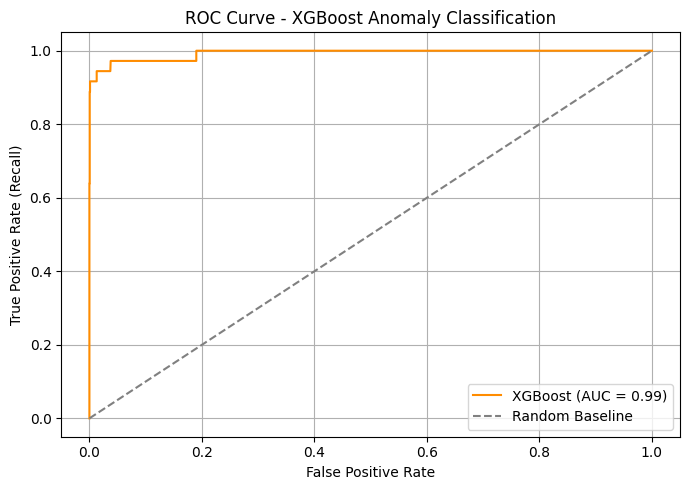

In [62]:
# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - XGBoost Anomaly Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The model almost perfectly separates the two classes. The curve hugging the top left corner indicates high true positive rate with minimal mistakes.

### Determine feature performance from XGBoost model

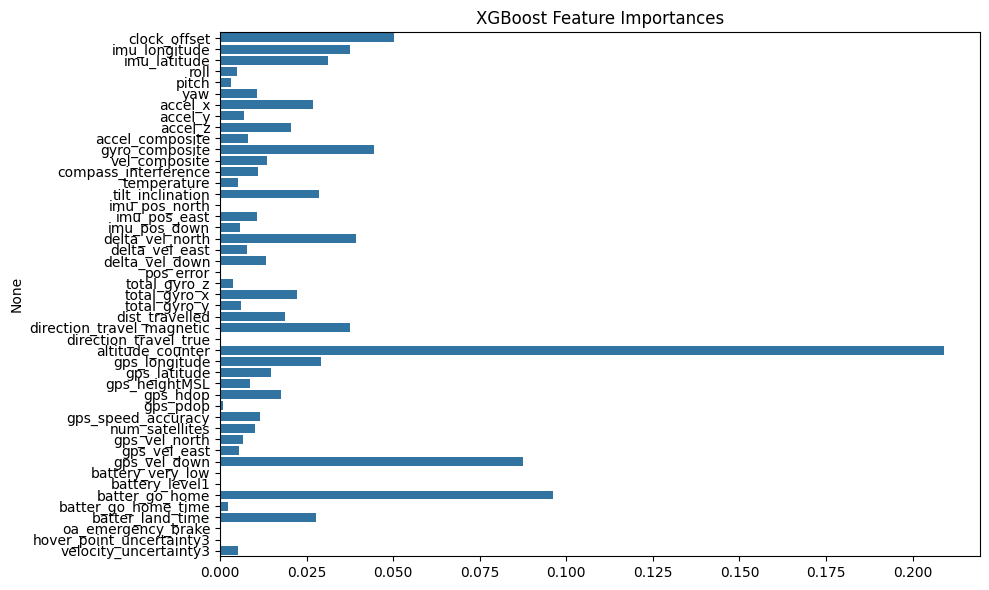

In [63]:
importances = grid.best_estimator_.feature_importances_
features = X_train.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()


# Ethical Check

Bias and False Positives: Even though the model performs with high accuracy and precision, it's important to recognize that false positives could lead to unnecessary system interventions. This could be caused by external factors such as weather, faulty sensor readings, or intentional behavior from user.  

Transparency and Interpretibility: Using feature importance visualization brings more interpretable features and model predictions. Additionally, using traditional machine learning techniques brings more clarity and explainability on how results were reached.

Sensor Reliability and Data Quality: Models rely on the telemetry data, and incorrect readings from sensors may lead to reported anomalies on normal behavior.

# Conclusions

In this project, a robust anomaly detection system for drone telemetry data was developed by combining unsupervised and supervised machine learning tasks. Using Isolation Forest, we identified potential outliers across features. The created labels were then used to train an XGBoost classifier, achieving a test accuracy of 99.67%, macro F1-score of 96%, and an AUC of 0.99, indicating strong generalization and precision even under class imbalance.

Through data exploration and visualization, the model's predictions aligned with sensor behavior. Feature importance analysis further demonstrated model's reliance on interpretable, flight-critical variables.

In [64]:
# Save the modified dataset
flight_anomaly.to_csv("flight_anomaly_dataset.csv", index=False)

In [65]:
# Save the model
joblib.dump(xgb, "xgb_anomaly_model.pkl")

['xgb_anomaly_model.pkl']

In [ ]:
!pip install nbconvert
# You also need to install latex-related package in order to convert a notebook to pdf file.
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc

In [ ]:
!cp drive/MyDrive/Colab\ Notebooks/flight_anomaly_model.ipynb ./
!jupyter nbconvert --to pdf flight_anomaly_model.ipynb